<a href="https://colab.research.google.com/github/Huhhuu/DataDeepLearning/blob/main/Lab2_TH_DEEPLEARNING_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NAP THU VIEN

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    log_loss
)

from sklearn.model_selection import (
    cross_val_score,
    cross_validate
)

from sklearn.preprocessing import MinMaxScaler

# tải bộ dữ liệu Fashion MNIST

In [ ]:


fashion = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


#XU LI DU LIEU

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# reshape từ 28x28 -> 784
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# feature scaling
minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

# kiểm tra
print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
X_train shape: (60000, 784)
X_test shape: (10000, 784)


#TRUC QUAN HOA DU LIEU

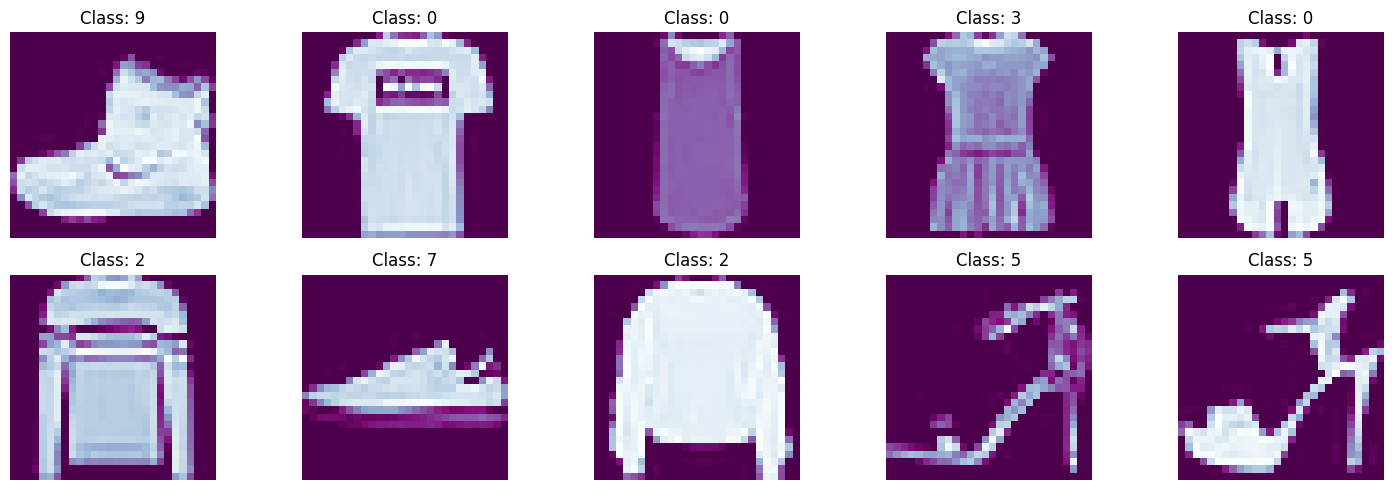

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(15,5))

ax = ax.ravel()

for i in range(10):
    ax[i].imshow(X_train[i].reshape(28,28), cmap='BuPu_r')
    ax[i].set_title('Class: ' + str(y_train[i]))
    ax[i].axis('off')

plt.tight_layout()
plt.show()

#Xay dung mo hinh ANN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

fashion_model = Sequential()

# INPUT + HIDDEN LAYER
fashion_model.add(
    Dense(
        units=256,
        activation='relu',
        kernel_initializer='uniform',
        input_shape=(X_train.shape[1],)
    )
)

# OUTPUT LAYER
fashion_model.add(
    Dense(
        units=10,
        activation='softmax',
        kernel_initializer='uniform'
    )
)

# COMPILE MODEL
fashion_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# MODEL SUMMARY
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

#Huan luyen ANN model

In [ ]:
model_fit = fashion_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9402 - loss: 0.1597 - val_accuracy: 0.8903 - val_loss: 0.3530
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9424 - loss: 0.1556 - val_accuracy: 0.8883 - val_loss: 0.3672
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9449 - loss: 0.1466 - val_accuracy: 0.8938 - val_loss: 0.3614
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9446 - loss: 0.1460 - val_accuracy: 0.8890 - val_loss: 0.3804
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9464 - loss: 0.1429 - val_accuracy: 0.8943 - val_loss: 0.3834
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9487 - loss: 0.1366 - val_accuracy: 0.8890 - val_loss: 0.3789
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9494 - loss: 0.1356 - val_accuracy: 0.8928 - val_loss: 0.3880
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9509 - loss: 0.1

#Danh gia mo hinh ANN

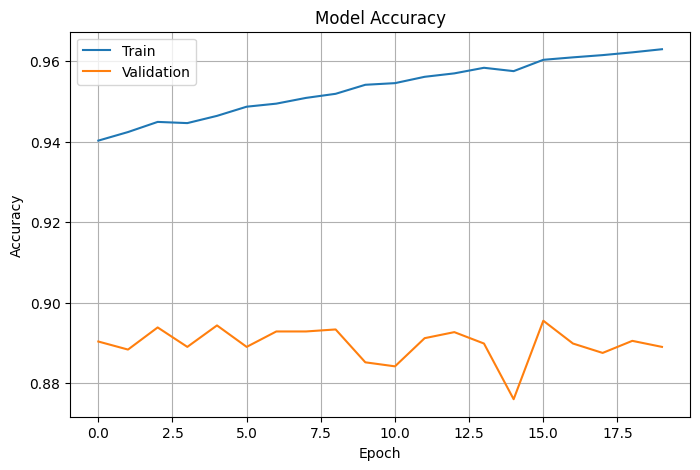

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.grid(True)

plt.show()

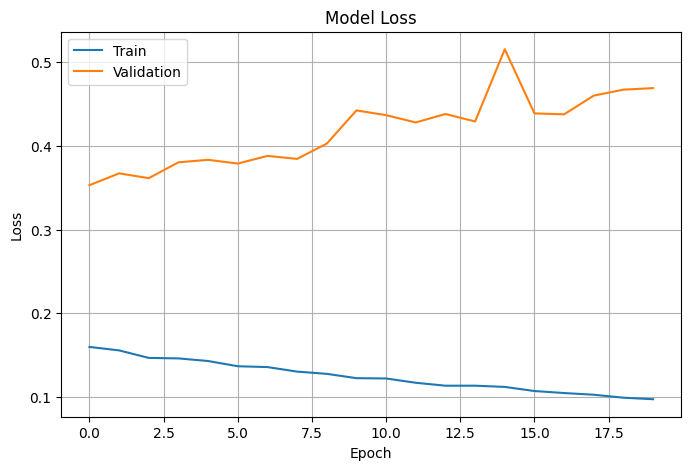

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.grid(True)

plt.show()

#Du bao anh moi

In [ ]:
predictions = fashion_model.predict(X_test)

print("Predicted:", np.argmax(predictions[0]))
print("Actual:", y_test[0])

print("-------------------")

print("Predicted:", np.argmax(predictions[10]))
print("Actual:", y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: 9
Actual: 9
-------------------
Predicted: 4
Actual: 4


#BAI TAP
BAI TAP 1

In [ ]:
# IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import cifar10

In [ ]:
#LOAD CIFAR-10 DATASET
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
X_train: (50000, 32, 32, 3)
y_train: (50000, 1)
X_test: (10000, 32, 32, 3)
y_test: (10000, 1)


In [ ]:
#CLASS LABELS
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

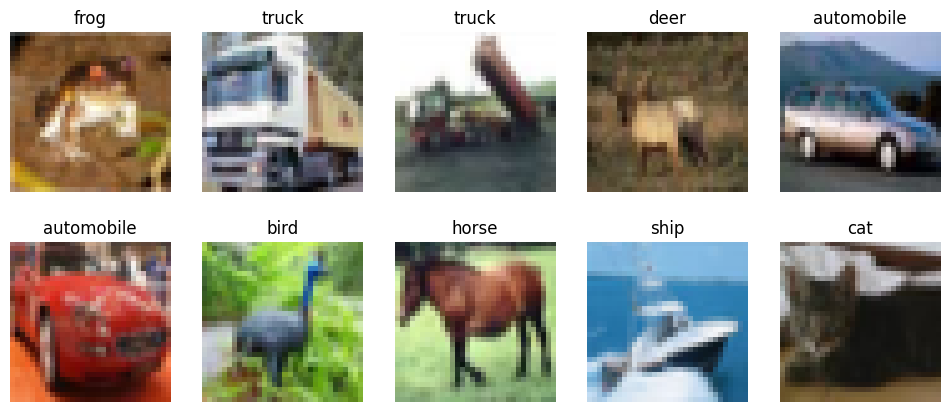

In [ ]:
# DATA VISUALIZATION
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [ ]:
# NORMALIZE DATA
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# BUILD ANN MODEL
model = Sequential()

model.add(Flatten(input_shape=(32, 32, 3)))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TRAIN ANN MODEL
model_fit = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4233 - loss: 1.5925 - val_accuracy: 0.4358 - val_loss: 1.6079
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4226 - loss: 1.5966 - val_accuracy: 0.4490 - val_loss: 1.5535
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4239 - loss: 1.5877 - val_accuracy: 0.4478 - val_loss: 1.5813
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4230 - loss: 1.5881 - val_accuracy: 0.4470 - val_loss: 1.5663
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4254 - loss: 1.5826 - val_accuracy: 0.4502 - val_loss: 1.5671
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4297 - loss: 1.5735 - val_accuracy: 0.4568 - val_loss: 1.5456
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4277 - loss: 1.5820 - val_accuracy: 0.4418 - val_loss: 1.5762
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.4286 - loss: 1.5784 - 

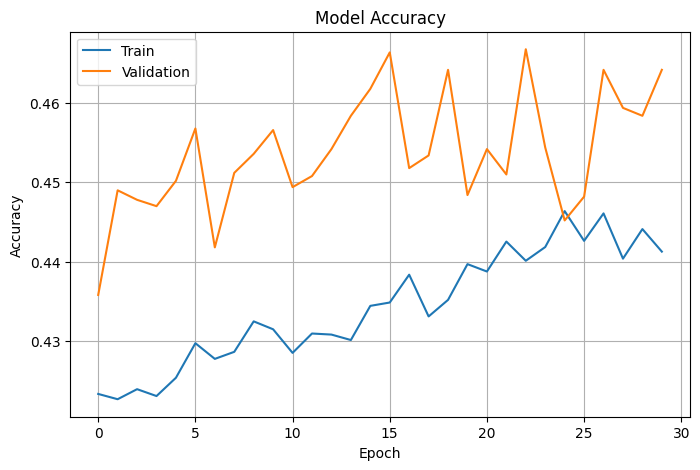

In [ ]:
# PLOT ACCURACY
plt.figure(figsize=(8,5))

plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.show()

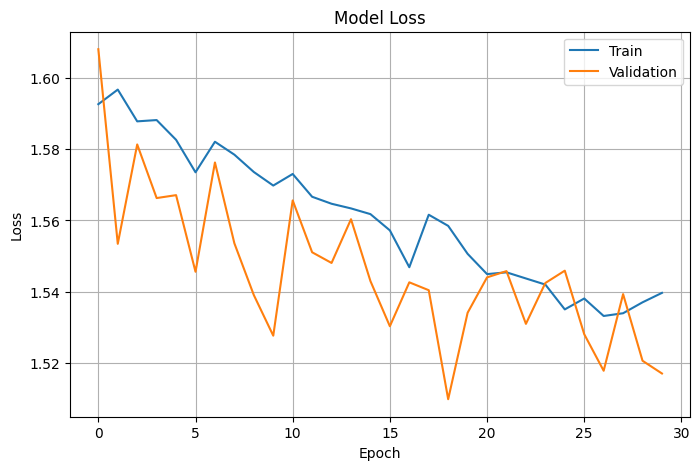

In [ ]:
# PLOT LOSS
plt.figure(figsize=(8,5))

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

plt.show()

In [ ]:
# EVALUATE MODEL
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4606 - loss: 1.5263
Test Accuracy: 0.46059998869895935
Test Loss: 1.5263288021087646


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


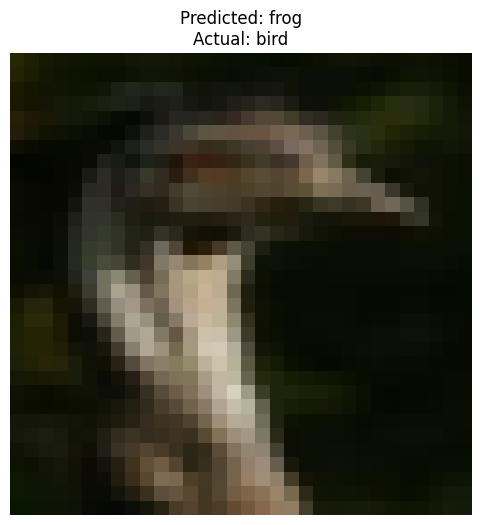

In [ ]:
import random
# PREDICT IMAGE

predictions = model.predict(X_test)

index = random.randint(0, len(X_test)-1)

plt.figure(figsize=(6,6))

plt.imshow(X_test[index])

plt.title(
    "Predicted: " + class_names[np.argmax(predictions[index])] +
    "\nActual: " + class_names[y_test[index][0]]
)

plt.axis('off')

plt.show()

#CAI DAT ANN DE NHAN DIEN ANH MEO HOAC CHO

tai package kagglehub

In [ ]:
!pip install kagglehub

cai data

In [3]:
import kagglehub

path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [4]:
import os

for root, dirs, files in os.walk(path):
    print(root, len(files))

/kaggle/input/cat-and-dog 0
/kaggle/input/cat-and-dog/test_set 0
/kaggle/input/cat-and-dog/test_set/test_set 0
/kaggle/input/cat-and-dog/test_set/test_set/dogs 1013
/kaggle/input/cat-and-dog/test_set/test_set/cats 1012
/kaggle/input/cat-and-dog/training_set 0
/kaggle/input/cat-and-dog/training_set/training_set 0
/kaggle/input/cat-and-dog/training_set/training_set/dogs 4006
/kaggle/input/cat-and-dog/training_set/training_set/cats 4001


tim folder chua anh

In [5]:
import os

image_folder = None

for root, dirs, files in os.walk(path):
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(image_files) > 0:
        image_folder = root
        print("Image folder:", image_folder)
        print("Number of images:", len(image_files))
        break

Image folder: /kaggle/input/cat-and-dog/test_set/test_set/dogs
Number of images: 1012


Doc anh, resize, luu anh

In [6]:
from os import listdir
from numpy import asarray, save
from tensorflow.keras.preprocessing.image import load_img, img_to_array

photos, labels = list(), list()

for file in listdir(image_folder):
    if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    output = 0.0

    if file.lower().startswith('dog'):
        output = 1.0

    photo = load_img(
        os.path.join(image_folder, file),
        target_size=(200, 200)
    )

    photo = img_to_array(photo)

    photos.append(photo)
    labels.append(output)

photos = asarray(photos)
labels = asarray(labels)

print("Photos shape:", photos.shape)
print("Labels shape:", labels.shape)

save('dogs_vs_cats_photos.npy', photos)
save('dogs_vs_cats_labels.npy', labels)

Photos shape: (1012, 200, 200, 3)
Labels shape: (1012,)


#Huan luyen ANN model
tai thu vien

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [8]:
photos = np.load('dogs_vs_cats_photos.npy')
labels = np.load('dogs_vs_cats_labels.npy')

print(photos.shape)
print(labels.shape)

(1012, 200, 200, 3)
(1012,)


In [9]:
X = photos.reshape(photos.shape[0], 200 * 200 * 3)
y = labels

X = X / 255.0

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

xay dung model

In [11]:
model = Sequential()

model.add(Dense(512, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    61,440,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,604,865 (235.00 MB)

 Trainable params: 61,604,865 (235.00 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9629 - loss: 0.0410 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 1.00

In [13]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Loss: 0.0
Test Accuracy: 1.0


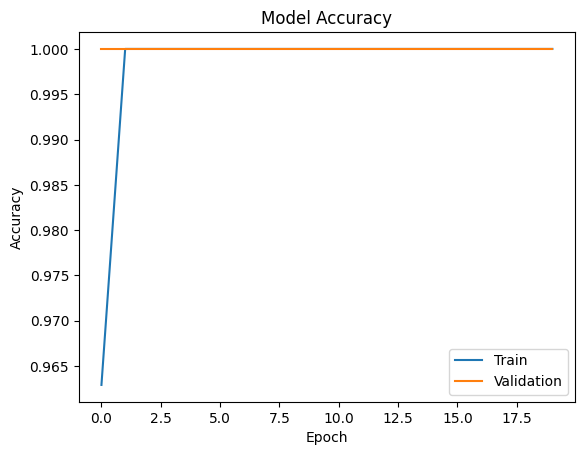

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


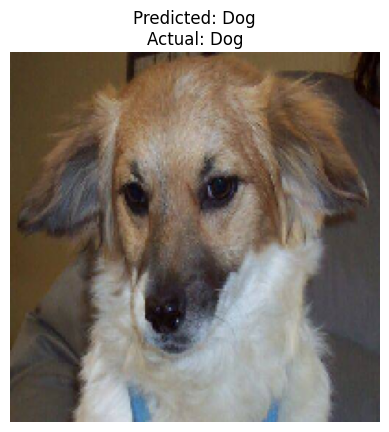

In [41]:
import random

index = random.randint(0, len(X_test)-1)

prediction = model.predict(X_test[index].reshape(1, -1))[0][0]

predicted_label = "Dog" if prediction >= 0.5 else "Cat"
actual_label = "Dog" if y_test[index] == 1 else "Cat"

plt.imshow(X_test[index].reshape(200, 200, 3))
plt.title(
    "Predicted: " + predicted_label +
    "\nActual: " + actual_label
)
plt.axis('off')
plt.show()